In [1]:
import json
from tqdm import tqdm
from pathlib import Path

import copy
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset

device = 'cuda' if torch.cuda.is_available() else 'cpu'

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [2]:
# Root Path
ROOT = Path("Amazon_products")

# Train and Test Dataset
TRAIN_CORPUS_PATH = ROOT / "train" /  "train_corpus.txt"
TEST_CORPUS_PATH = ROOT / "test" / "test_corpus.txt"

# Taxonomy
CLASSES_PATH = ROOT / "classes.txt"
HIERARCHY_PATH = ROOT / "class_hierarchy.txt"
KEYWORDS_PATH = ROOT / "class_related_keywords.txt"

In [3]:
import matplotlib.pyplot as plt
from collections import defaultdict
import itertools

# ------------------------
# Function for loads
# ------------------------

def load_lines(p: Path):
    with p.open("r", encoding="utf-8") as f:
        return [line.rstrip("\n") for line in f]

def load_pid2text(p: Path):
    """TSV: pid \\t text  -> dict[pid]=text"""
    pid2text = {}
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t", 1)
            if len(parts) == 2:
                pid, text = parts
                pid2text[pid] = text
    return pid2text

def load_classes_int(p: Path):
    class_dict = {}
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            label_int, label_str = line.rstrip("\n").split("\t")
            class_dict[int(label_int)] = label_str
    return class_dict

def load_keywords(p: Path):
    keywords = {}
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            key, items = line.rstrip("\n").split(":")
            item_list = [item for item in items.split(",")]
            keywords[key] = item_list
    return keywords

def load_class_graph(p: Path):
    edges = []
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            p, c = map(int, line.rstrip("\n").split("\t"))
            edges.append((p, c))
    return edges

def load_json(path):
    """Load JSON file into Python object."""
    with open(path) as f:
        return json.load(f)

# ------------------------
# Visualization
# ------------------------

def plot_results(results_dict, split="valid", metric="Loss"):
    """
    Plot metric (e.g., loss) values over epochs for multiple models.

    Args:
        results_dict: dict of dicts
            Example:
                results_dict["valid"]["mlp_partial"] = [0.69, 0.65, ...]
        split: "train" | "valid" | "test"
        metric: name of the metric to display (default: Loss)
    """
    assert split in results_dict, f"{split} not in results_dict"

    plt.figure(figsize=(8, 5))

    for label, value_list in results_dict[split].items():
        plt.plot(
            range(1, len(value_list) + 1),
            value_list,
            marker="o",
            label=label
        )

    plt.title(f"{split.capitalize()} {metric} over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [4]:
# ---------- Read-only loads ----------

train_pid2text    = load_pid2text(TRAIN_CORPUS_PATH)
test_pid2text     = load_pid2text(TEST_CORPUS_PATH)
pid2class         = load_classes_int(CLASSES_PATH)
rel_keywords      = load_keywords(KEYWORDS_PATH)
class_graph_edges = load_class_graph(HIERARCHY_PATH)

NUM_CLASSES = len(pid2class)
print(f"#train={len(train_pid2text):,}  #test={len(test_pid2text):,}")

#train=29,487  #test=19,658


# MLP only training

In [5]:
EMB_PATH = ROOT / "Embeddings"

train_emb_dict = load_json(EMB_PATH / "train_embeddings.json")
test_emb_dict = load_json(EMB_PATH / "test_embeddings.json")
class_emb_dict = load_json(EMB_PATH / "class_embeddings.json")
class_llm_emb_dict = load_json(EMB_PATH / "class_llm_embeddings.json")

train_doc_emb = np.stack(list(train_emb_dict.values()))   # (N_train, D)
test_doc_emb  = np.stack(list(test_emb_dict.values()))    # (N_test, D)
class_name_emb = np.stack(list(class_emb_dict.values()))  # (NUM_CLASSES, D)
class_llm_emb = np.stack(list(class_llm_emb_dict.values()))  # (NUM_CLASSES, D)

In [6]:
Y_silver_df = pd.read_csv("Silver Core/Y_silver.csv")
Y_silver = Y_silver_df.to_numpy(dtype=np.float32)

In [7]:
class EmbeddingDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        assert X.shape[0] == y.shape[0]
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [8]:
dataset = EmbeddingDataset(train_doc_emb, Y_silver)

# train / valid : 0.9 / 0.1
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

g = torch.Generator().manual_seed(42)
train_split, val_split = random_split(dataset, [train_size, val_size], generator=g)

train_loader = DataLoader(train_split, batch_size=32, shuffle=True)
valid_loader = DataLoader(val_split, batch_size=32, shuffle=False)

In [9]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_labels, hidden_dim=512, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_labels)
        )

    def forward(self, x):
        return self.net(x)

In [10]:
input_dim = train_doc_emb.shape[1]
model = MLPClassifier(input_dim, NUM_CLASSES, hidden_dim=512).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

In [11]:
from sklearn.metrics import f1_score

EPOCHS = 100

thres = 0.5
best_val_loss = 1.0
wait_time = 10
cnt = 0
best_model_state = copy.deepcopy(model.state_dict())

train_losses, valid_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # =========== Train ===========
    model.train()
    total_loss = 0.0

    for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch} [Train]"):
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

    avg_train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # ========== Validation ===========
    model.eval()
    total_vloss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            total_vloss += loss.item() * batch_x.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs > thres).float()

            all_preds.append(preds.cpu())
            all_labels.append(batch_y.cpu())

    avg_val_loss = total_vloss / len(valid_loader.dataset)
    valid_losses.append(avg_val_loss)

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    print(
        f"[Epoch {epoch:03d}] "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}\n"
    )

    # Early Stopping (val loss 기준)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        cnt = 0
    else:
        cnt += 1
        if cnt >= wait_time:
            print(f"No improvement in val loss for {cnt} epochs. Early stopping.")
            break

model.load_state_dict(best_model_state)
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 1 [Train]: 100%|██████████| 830/830 [00:01<00:00, 680.91it/s]


[Epoch 001] Train Loss: 0.0459 | Val Loss: 0.0218



Epoch 2 [Train]: 100%|██████████| 830/830 [00:01<00:00, 729.05it/s]


[Epoch 002] Train Loss: 0.0187 | Val Loss: 0.0154



Epoch 3 [Train]: 100%|██████████| 830/830 [00:01<00:00, 746.82it/s]


...

[Epoch 027] Train Loss: 0.0039 | Val Loss: 0.0083



Epoch 28 [Train]: 100%|██████████| 830/830 [00:00<00:00, 911.11it/s]


[Epoch 028] Train Loss: 0.0038 | Val Loss: 0.0083



Epoch 29 [Train]: 100%|██████████| 830/830 [00:00<00:00, 911.30it/s]

[Epoch 029] Train Loss: 0.0037 | Val Loss: 0.0082

No improvement in val loss for 10 epochs. Early stopping.
Best validation loss: 0.0079


In [12]:
results_dict = {'losses':{}}

results_dict['losses']['train'] = train_losses[:]
results_dict['losses']['valid'] = valid_losses[:]

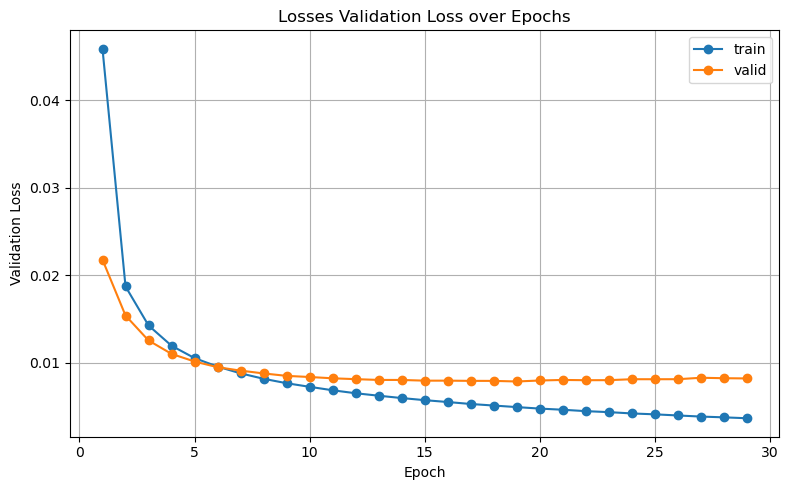

In [13]:
plot_results(results_dict, split="losses", metric="Validation Loss")

In [14]:
model.eval()
with torch.no_grad():
    test_x = torch.from_numpy(test_doc_emb).float().to(device)
    test_logits = model(test_x)
    test_probs = torch.sigmoid(test_logits).cpu().numpy()   # (N_test, NUM_CLASSES)

TOP_K_PRED = 3
THRESHOLD = 0.5

topk_indices = np.argsort(-test_probs, axis=1)[:, :TOP_K_PRED]  # (N_test, K)

labels_str_list = []

for i in range(test_probs.shape[0]):
    selected = []

    for cid in topk_indices[i]:
        if test_probs[i, cid] >= THRESHOLD:
            selected.append(str(int(cid)))

    # fallback: 아무것도 없으면 top-1은 무조건 포함
    if len(selected) == 0:
        selected.append(str(int(topk_indices[i, 0])))

    labels_str_list.append(",".join(selected))

submission = pd.DataFrame({
    "id": np.arange(len(test_doc_emb)).astype(str),
    "labels": labels_str_list
})


SUBMISSION_PATH = Path("Outputs") / "mpnet_mlp.csv"
SUBMISSION_PATH.parent.mkdir(exist_ok=True, parents=True)
submission.to_csv(SUBMISSION_PATH, index=False, encoding="utf-8")

print("Saved submission to:", SUBMISSION_PATH)

Saved submission to: Outputs/mpnet_mlp.csv


## Self Training

In [15]:
model.eval()
with torch.no_grad():
    X = torch.from_numpy(train_doc_emb).float().to(device)
    logits = model(X)
    probs = torch.sigmoid(logits).cpu().numpy()  # (N_train, C)


In [16]:
TOP_K = 3
THRESH = 0.7
CONF_THRESH = 0.5
N, C = probs.shape

topk_idx = np.argsort(-probs, axis=1)[:, :TOP_K]

pseudo_labels = np.zeros_like(probs, dtype=np.float32)
for i in range(N):
    pseudo_labels[i, topk_idx[i]] = probs[i, topk_idx[i]]

pseudo_labels = (pseudo_labels >= THRESH).astype(np.float32)

empty_rows = pseudo_labels.sum(axis=1) == 0
fallback_idx = probs[empty_rows].argmax(axis=1)
pseudo_labels[empty_rows, fallback_idx] = 1.0

confidence = probs.max(axis=1)
pseudo_mask = confidence >= CONF_THRESH

final_labels = Y_silver * pseudo_labels

empty_after = final_labels.sum(axis=1) == 0
final_labels[empty_after] = Y_silver[empty_after]

Y_final_torch = torch.from_numpy(final_labels).float().to(device)
pseudo_mask_torch = torch.from_numpy(pseudo_mask).to(device)


In [17]:
dataset_st = EmbeddingDataset(train_doc_emb, Y_final_torch.cpu().numpy())

train_size = int(0.9 * len(dataset_st))
val_size = len(dataset_st) - train_size

g = torch.Generator().manual_seed(42)
train_split, val_split = random_split(dataset_st, [train_size, val_size], generator=g)

train_loader = DataLoader(train_split, batch_size=32, shuffle=True)
valid_loader = DataLoader(val_split, batch_size=32, shuffle=False)

In [18]:
from sklearn.metrics import f1_score

EPOCHS = 50

thres = 0.5
best_val_loss = 1.0
wait_time = 10
cnt = 0
best_model_state = copy.deepcopy(model.state_dict())

train_losses, valid_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # =========== Train ===========
    model.train()
    total_loss = 0.0

    for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch} [Train]"):
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

    avg_train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # ========== Validation ===========
    model.eval()
    total_vloss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            total_vloss += loss.item() * batch_x.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs > thres).float()

            all_preds.append(preds.cpu())
            all_labels.append(batch_y.cpu())

    avg_val_loss = total_vloss / len(valid_loader.dataset)
    valid_losses.append(avg_val_loss)

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    print(
        f"[Epoch {epoch:03d}] "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}\n"
    )

    # Early Stopping (val loss 기준)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        cnt = 0
    else:
        cnt += 1
        if cnt >= wait_time:
            print(f"No improvement in val loss for {cnt} epochs. Early stopping.")
            break

model.load_state_dict(best_model_state)
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 1 [Train]: 100%|██████████| 830/830 [00:00<00:00, 951.83it/s]


[Epoch 001] Train Loss: 0.0037 | Val Loss: 0.0028



Epoch 2 [Train]: 100%|██████████| 830/830 [00:00<00:00, 992.49it/s]


[Epoch 002] Train Loss: 0.0030 | Val Loss: 0.0028



Epoch 3 [Train]: 100%|██████████| 830/830 [00:00<00:00, 986.60it/s]


...

[Epoch 012] Train Loss: 0.0017 | Val Loss: 0.0029



Epoch 13 [Train]: 100%|██████████| 830/830 [00:00<00:00, 980.33it/s]


[Epoch 013] Train Loss: 0.0016 | Val Loss: 0.0030



Epoch 14 [Train]: 100%|██████████| 830/830 [00:00<00:00, 991.87it/s]

[Epoch 014] Train Loss: 0.0015 | Val Loss: 0.0029

No improvement in val loss for 10 epochs. Early stopping.
Best validation loss: 0.0028


In [19]:
results_dict['losses']['valid_self'] = valid_losses[:]

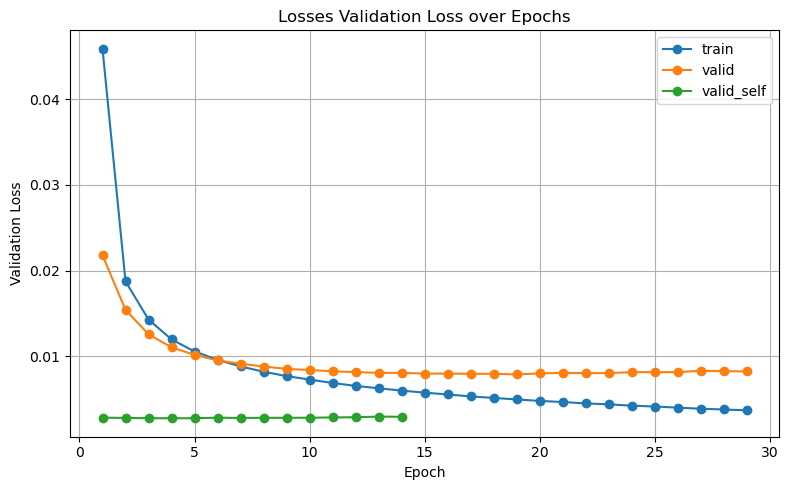

In [20]:
plot_results(results_dict, split="losses", metric="Validation Loss")

In [21]:
model.eval()
with torch.no_grad():
    test_x = torch.from_numpy(test_doc_emb).float().to(device)
    test_logits = model(test_x)
    test_probs = torch.sigmoid(test_logits).cpu().numpy()   # (N_test, NUM_CLASSES)

TOP_K_PRED = 3
THRESHOLD = 0.5

topk_indices = np.argsort(-test_probs, axis=1)[:, :TOP_K_PRED]  # (N_test, K)

labels_str_list = []

for i in range(test_probs.shape[0]):
    selected = []

    for cid in topk_indices[i]:
        if test_probs[i, cid] >= THRESHOLD:
            selected.append(str(int(cid)))

    # fallback: 아무것도 없으면 top-1은 무조건 포함
    if len(selected) == 0:
        selected.append(str(int(topk_indices[i, 0])))

    labels_str_list.append(",".join(selected))

submission = pd.DataFrame({
    "id": np.arange(len(test_doc_emb)).astype(str),
    "labels": labels_str_list
})


SUBMISSION_PATH = Path("Outputs") / "mpnet_mlp_self.csv"
SUBMISSION_PATH.parent.mkdir(exist_ok=True, parents=True)
submission.to_csv(SUBMISSION_PATH, index=False, encoding="utf-8")

print("Saved submission to:", SUBMISSION_PATH)

Saved submission to: Outputs/mpnet_mlp_self.csv
